# 07 — Time-Series Analysis of European Nighttime Brightness (2013–2024)

**Research question:** How have nighttime brightness levels evolved across European cities
over the 2013–2024 period, and can we identify statistically meaningful temporal trends
and forecast near-term trajectories?

This notebook applies a suite of time-series methods — parametric and non-parametric trend
estimation, stationarity testing, autocorrelation analysis, and ARIMA modelling — to the
annual VIIRS nighttime brightness composites for 30 European cities.

**Important caveat on temporal resolution:** The dataset contains only **annual** composites
(one observation per city per year, $n = 12$ years). Monthly VIIRS radiance data exist and
would enable seasonal decomposition and more powerful time-series modelling, but were not
used here due to data-volume constraints. All statistical tests and models should be
interpreted with this short-series limitation in mind.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.stats import kendalltau, theilslopes
from IPython.display import display

# Reproducibility
np.random.seed(42)

# ── Style config ──────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Imports and style config loaded.")

C:\Users\brian\AppData\Roaming\Python\Python310\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports and style config loaded.


## 1 Data

We load the merged analysis panel (`analysis_panel.csv`) containing 30 European cities
observed over 12 years (2013–2024). The target variable is `mean_brightness`
(nW/cm²/sr), the average radiance within each city’s VIIRS footprint.

In [2]:
# ── Load the analysis panel ─────────────────────────────────────────────────────────
file_path = Path("../data/processed/analysis_panel.csv")
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
if "year" in df.columns:
    year_numeric = pd.to_numeric(df["year"], errors="coerce")
    if isinstance(year_numeric, pd.Series):
        df["year"] = year_numeric.astype("Int64")

print(f"Shape: {df.shape}")
print(f"Year range: {df['year'].min()} \u2013 {df['year'].max()}")
print(f"Number of cities: {df['city'].nunique()}")
print(f"\nBrightness summary statistics:")
display(df["mean_brightness"].describe().to_frame().T)

Shape: (360, 37)
Year range: 2013 – 2024
Number of cities: 30

Brightness summary statistics:


,count,mean,std,min,25%,50%,75%,max
mean_brightness,360.0,13.202143,10.512468,3.571708,7.111415,10.045259,16.829421,71.945402


## 2 Aggregate European Brightness Trend

Before examining individual cities, we compute the **cross-city mean brightness** for each
year. This aggregate series smooths out city-specific noise and reveals whether there is a
continent-wide directional shift in nighttime radiance. We fit an OLS trendline and overlay
a 95% confidence band derived from the standard error of the regression.

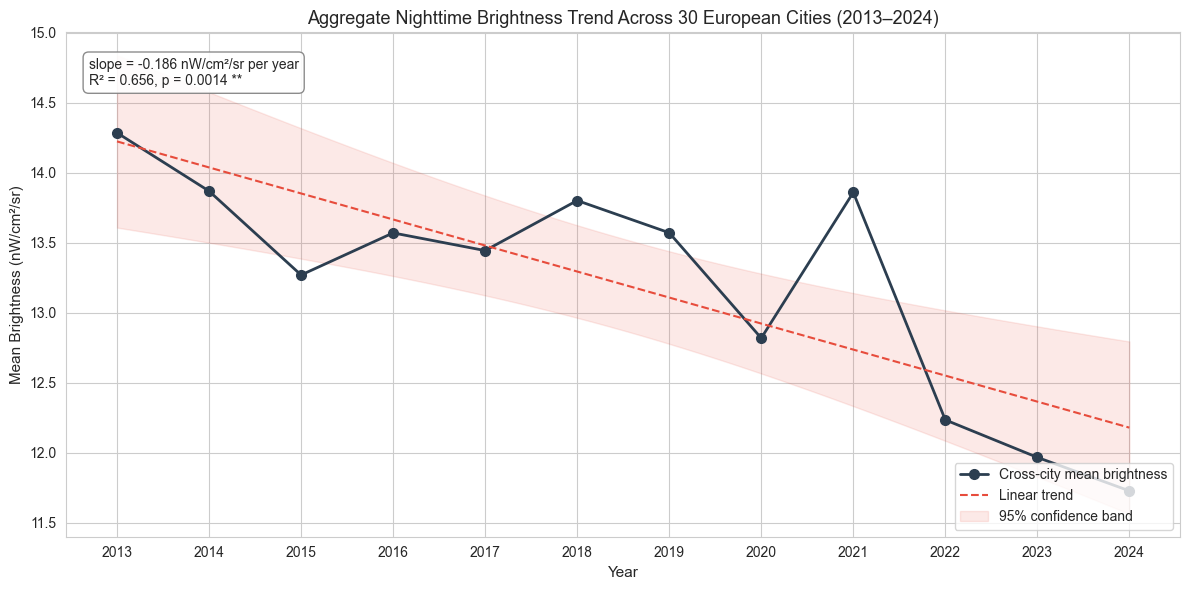


Aggregate linear trend: -0.1857 nW/cm²/sr per year (p = 0.0014)


In [3]:
# ── Aggregate trend: cross-city mean brightness per year ────────────────────────
agg = df.groupby("year")["mean_brightness"].mean().reset_index()
agg.columns = ["year", "avg_brightness"]

# Linear regression on the aggregate series
slope, intercept, r_value, p_value, std_err = stats.linregress(
    agg["year"].astype(float), agg["avg_brightness"]
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(agg["year"], agg["avg_brightness"], "o-", color="#2c3e50", lw=2,
        markersize=7, label="Cross-city mean brightness")

# Trendline with 95% confidence band
x_fit = np.linspace(agg["year"].min(), agg["year"].max(), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, "--", color="#e74c3c", lw=1.5, label="Linear trend")

# 95% CI band: y_hat +/- t_crit * SE * sqrt(1/n + (x - x_bar)^2 / SS_x)
n_agg = len(agg)
x_mean = agg["year"].astype(float).mean()
ss_x = ((agg["year"].astype(float) - x_mean) ** 2).sum()
residuals = agg["avg_brightness"] - (slope * agg["year"].astype(float) + intercept)
se_resid = np.sqrt((residuals ** 2).sum() / (n_agg - 2))
t_crit = stats.t.ppf(0.975, df=n_agg - 2)
ci_band = t_crit * se_resid * np.sqrt(1 / n_agg + (x_fit - x_mean) ** 2 / ss_x)
ax.fill_between(x_fit, y_fit - ci_band, y_fit + ci_band,
                color="#e74c3c", alpha=0.12, label="95% confidence band")

# Annotation
sig_label = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "(n.s.)"
ax.annotate(
    f"slope = {slope:+.3f} nW/cm\u00b2/sr per year\n"
    f"R\u00b2 = {r_value**2:.3f}, p = {p_value:.4f} {sig_label}",
    xy=(0.02, 0.95), xycoords="axes fraction", fontsize=10,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9),
)

ax.set_xlabel("Year")
ax.set_ylabel("Mean Brightness (nW/cm\u00b2/sr)")
ax.set_title("Aggregate Nighttime Brightness Trend Across 30 European Cities (2013\u20132024)")
ax.legend(loc="lower right")
ax.set_xticks(agg["year"])

plt.tight_layout()
plt.savefig(FIG_DIR / "ts_aggregate_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAggregate linear trend: {slope:+.4f} nW/cm\u00b2/sr per year (p = {p_value:.4f})")

## 3 Per-City Trend Analysis

City-level trends are estimated using three complementary approaches:

| Method | Type | What it measures |
|--------|------|------------------|
| **OLS linear regression** | Parametric | Slope of brightness ~ year; sensitive to outliers |
| **Mann–Kendall (Kendall’s $\tau$)** | Non-parametric | Monotonic trend presence; rank-based, robust to non-normality |
| **Theil–Sen estimator** | Non-parametric | Median of pairwise slopes; resistant to outliers |

For short series ($n = 12$), the non-parametric methods are arguably more trustworthy
than OLS, since distributional assumptions are harder to verify. We report all three to
assess robustness of the trend estimates.

In [4]:
# ── Per-city trends: OLS + Mann-Kendall + Theil-Sen ──────────────────────────
trend_records = []
for city, grp in df.groupby("city"):
    grp_sorted = grp.sort_values("year")
    x = grp_sorted["year"].astype(float).values
    y = grp_sorted["mean_brightness"].values

    # OLS
    sl, ic, rv, pv, se = stats.linregress(x, y)

    # Mann-Kendall (via Kendall's tau on rank-order)
    tau, mk_p = kendalltau(range(len(y)), y)

    # Theil-Sen robust slope
    ts_slope, ts_intercept, ts_low, ts_high = theilslopes(y, x)

    trend_records.append({
        "city": city,
        "ols_slope": sl,
        "ols_r2": rv ** 2,
        "ols_p": pv,
        "ols_se": se,
        "ols_significant": pv < 0.05,
        "mk_tau": tau,
        "mk_p": mk_p,
        "mk_significant": mk_p < 0.05,
        "ts_slope": ts_slope,
        "ts_ci_low": ts_low,
        "ts_ci_high": ts_high,
    })

trends_df = pd.DataFrame(trend_records).sort_values("ols_slope", ascending=True)
trends_df = trends_df.reset_index(drop=True)

# Display summary table
display_cols = ["city", "ols_slope", "ols_p", "ols_significant",
                "mk_tau", "mk_p", "mk_significant", "ts_slope"]
print("Per-city trend summary (sorted by OLS slope):")
display(trends_df[display_cols])

# Agreement between methods
both_sig = ((trends_df["ols_significant"]) & (trends_df["mk_significant"])).sum()
print(f"\nCities significant by BOTH OLS and Mann-Kendall (p < 0.05): {both_sig}")
print(f"Cities with significant OLS decreasing trends: "
      f"{trends_df[(trends_df['ols_significant']) & (trends_df['ols_slope'] < 0)]['city'].tolist()}")
print(f"Cities with significant OLS increasing trends: "
      f"{trends_df[(trends_df['ols_significant']) & (trends_df['ols_slope'] > 0)]['city'].tolist()}")

Per-city trend summary (sorted by OLS slope):


,city,ols_slope,ols_p,ols_significant,mk_tau,mk_p,mk_significant,ts_slope
0,Rotterdam,-4.376078,3.538499e-05,True,-0.878788,5.319398e-06,True,-3.125044
1,Paris,-0.691737,4.557179e-03,True,-0.696970,9.744811e-04,True,-0.530509
2,Porto,-0.379181,7.691734e-06,True,-0.757576,2.400243e-04,True,-0.378099
3,Amsterdam,-0.362481,2.464605e-06,True,-0.878788,5.319398e-06,True,-0.348591
4,Madrid,-0.341775,4.355218e-02,True,-0.181818,4.590240e-01,False,-0.166766
5,Lyon,-0.320800,6.124336e-05,True,-0.909091,1.465548e-06,True,-0.269940
6,Lisbon,-0.306639,9.603742e-06,True,-0.818182,4.412929e-05,True,-0.295008
7,Brussels,-0.254533,8.453235e-03,True,-0.454545,4.473690e-02,True,-0.103415
8,Rome,-0.231130,7.350656e-03,True,-0.303030,1.969499e-01,False,-0.182878
9,Zagreb,-0.128159,8.257818e-05,True,-0.696970,9.744811e-04,True,-0.123608



Cities significant by BOTH OLS and Mann-Kendall (p < 0.05): 16
Cities with significant OLS decreasing trends: ['Rotterdam', 'Paris', 'Porto', 'Amsterdam', 'Madrid', 'Lyon', 'Lisbon', 'Brussels', 'Rome', 'Zagreb', 'Barcelona']
Cities with significant OLS increasing trends: ['Munich', 'Copenhagen', 'Vienna', 'Budapest', 'Sofia', 'Naples', 'Bucharest', 'Athens']


The following chart ranks all 30 cities by their OLS and Theil-Sen brightness
slopes. Bars extending left (green) indicate decreasing brightness; bars
extending right (orange) indicate increasing brightness. Black borders and
asterisks mark trends significant at $p < 0.05$. Rotterdam's extreme values
are clipped and annotated to preserve readability for the other 29 cities.


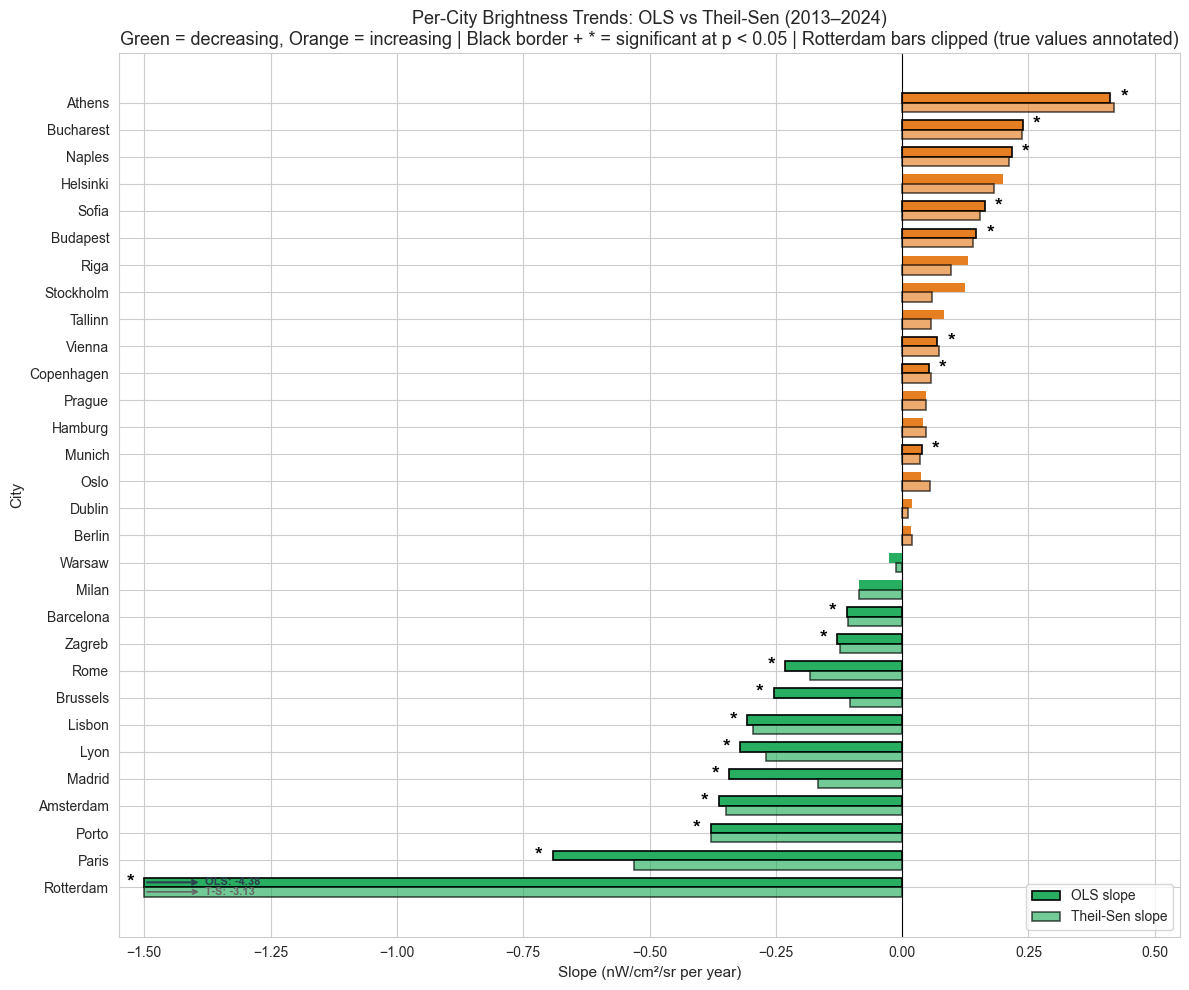

In [5]:
# ── Bar chart: OLS vs Theil-Sen slopes (Rotterdam clipped for readability) ──
fig, ax = plt.subplots(figsize=(12, 10))

y_positions = np.arange(len(trends_df))
bar_height = 0.35

# Clip extreme values for display (Rotterdam OLS ~ -4.4)
clip_min, clip_max = -1.5, 0.55
ols_clipped = trends_df['ols_slope'].clip(lower=clip_min)
ts_clipped = trends_df['ts_slope'].clip(lower=clip_min)

# OLS slopes
ols_colors = ['#27ae60' if s < 0 else '#e67e22' for s in trends_df['ols_slope']]
ols_edges = ['black' if sig else 'none' for sig in trends_df['ols_significant']]
ax.barh(y_positions + bar_height / 2, ols_clipped,
        height=bar_height, color=ols_colors, edgecolor=ols_edges,
        linewidth=1.2, label='OLS slope')

# Theil-Sen slopes
ts_colors = ['#27ae60' if s < 0 else '#e67e22' for s in trends_df['ts_slope']]
ts_edges = ['black' if sig else 'none' for sig in trends_df['mk_significant']]
ax.barh(y_positions - bar_height / 2, ts_clipped,
        height=bar_height, color=ts_colors, edgecolor=ts_edges,
        linewidth=1.2, alpha=0.65, label='Theil-Sen slope')

# Mark significance on OLS bars
for i, (sig, pv) in enumerate(zip(trends_df['ols_significant'], trends_df['ols_p'])):
    if sig:
        xpos = ols_clipped.iloc[i]
        offset = 0.02 if xpos >= 0 else -0.02
        ax.text(xpos + offset, i + bar_height / 2, '*', fontsize=14,
                fontweight='bold', va='center',
                ha='left' if xpos >= 0 else 'right', color='black')

# Annotate clipped bars with their true values
for idx_row in range(len(trends_df)):
    row = trends_df.iloc[idx_row]
    if row['ols_slope'] < clip_min:
        ax.annotate(
            f'OLS: {row["ols_slope"]:+.2f}',
            xy=(clip_min, idx_row + bar_height / 2),
            xytext=(clip_min + 0.12, idx_row + bar_height / 2),
            fontsize=8, fontweight='bold', color='#2c3e50', va='center',
            arrowprops=dict(arrowstyle='<-', color='#2c3e50', lw=1.5))
    if row['ts_slope'] < clip_min:
        ax.annotate(
            f'T-S: {row["ts_slope"]:+.2f}',
            xy=(clip_min, idx_row - bar_height / 2),
            xytext=(clip_min + 0.12, idx_row - bar_height / 2),
            fontsize=8, fontweight='bold', color='#666', va='center',
            arrowprops=dict(arrowstyle='<-', color='#666', lw=1.2))

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlim(clip_min - 0.05, clip_max)
ax.set_yticks(y_positions)
ax.set_yticklabels(trends_df['city'])
ax.set_xlabel('Slope (nW/cm\u00b2/sr per year)')
ax.set_ylabel('City')
ax.set_title('Per-City Brightness Trends: OLS vs Theil-Sen (2013\u20132024)\n'
             'Green = decreasing, Orange = increasing | '
             'Black border + * = significant at p < 0.05 | '
             'Rotterdam bars clipped (true values annotated)')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ts_city_slopes.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 Stationarity Testing

We apply the **Augmented Dickey–Fuller (ADF)** test to each city’s brightness series.
The null hypothesis is that the series contains a unit root (i.e., it is non-stationary);
rejection at $p < 0.05$ implies the series is stationary.

**Low-power caveat:** With only $n = 12$ observations and `maxlag=2`, the ADF test has
very limited statistical power. Failure to reject the null does *not* confirm a unit root
— it may simply reflect the short sample. We report critical values alongside the test
statistic so readers can gauge proximity to rejection thresholds.

In [6]:
# ── Stationarity testing: ADF per city with critical values ────────────────────
adf_records = []
for city, grp in df.groupby("city"):
    series = grp.sort_values("year")["mean_brightness"].values
    try:
        # maxlag is limited given the short series (12 obs)
        adf_stat, adf_p, used_lag, nobs, crit_vals, icbest = adfuller(
            series, maxlag=2, autolag="AIC"
        )
        adf_records.append({
            "city": city,
            "adf_statistic": round(adf_stat, 4),
            "p_value": round(adf_p, 4),
            "lags_used": used_lag,
            "cv_1pct": round(crit_vals["1%"], 4),
            "cv_5pct": round(crit_vals["5%"], 4),
            "cv_10pct": round(crit_vals["10%"], 4),
            "stationary": "Yes" if adf_p < 0.05 else "No",
        })
    except Exception as e:
        adf_records.append({
            "city": city,
            "adf_statistic": np.nan,
            "p_value": np.nan,
            "lags_used": np.nan,
            "cv_1pct": np.nan,
            "cv_5pct": np.nan,
            "cv_10pct": np.nan,
            "stationary": f"Error: {e}",
        })

adf_df = pd.DataFrame(adf_records)

print("Augmented Dickey-Fuller Stationarity Test Results")
print("(Critical values shown at 1%, 5%, 10% significance levels)")
display(adf_df)

n_stationary = (adf_df["stationary"] == "Yes").sum()
n_nonstationary = (adf_df["stationary"] == "No").sum()
print(f"\nStationary (p < 0.05): {n_stationary} cities")
print(f"Non-stationary: {n_nonstationary} cities")

Augmented Dickey-Fuller Stationarity Test Results
(Critical values shown at 1%, 5%, 10% significance levels)


,city,adf_statistic,p_value,lags_used,cv_1pct,cv_5pct,cv_10pct,stationary
0,Amsterdam,-0.1829,0.9405,0,-4.2232,-3.1894,-2.7298,No
1,Athens,2.6157,0.9991,0,-4.2232,-3.1894,-2.7298,No
2,Barcelona,-3.4761,0.0086,0,-4.2232,-3.1894,-2.7298,Yes
3,Berlin,-2.1393,0.2290,0,-4.2232,-3.1894,-2.7298,No
4,Brussels,0.7340,0.9905,0,-4.2232,-3.1894,-2.7298,No
5,Bucharest,0.6949,0.9897,1,-4.3316,-3.2330,-2.7487,No
6,Budapest,-0.8506,0.8038,1,-4.3316,-3.2330,-2.7487,No
7,Copenhagen,-1.9183,0.3235,0,-4.2232,-3.1894,-2.7298,No
8,Dublin,-2.4696,0.1230,1,-4.3316,-3.2330,-2.7487,No
9,Hamburg,-2.1844,0.2120,0,-4.2232,-3.1894,-2.7298,No



Stationary (p < 0.05): 5 cities
Non-stationary: 25 cities


## 5 Autocorrelation Structure

Before fitting ARIMA models, we inspect the **autocorrelation function (ACF)** and
**partial autocorrelation function (PACF)** for three representative cities:
Athens (increasing), Amsterdam (decreasing), and Berlin (stable).

With only 12 observations, we limit the analysis to `nlags=5`. The ACF and PACF
will be noisy at this sample size, but they still provide useful guidance for
ARIMA order selection ($p$ from PACF, $q$ from ACF).

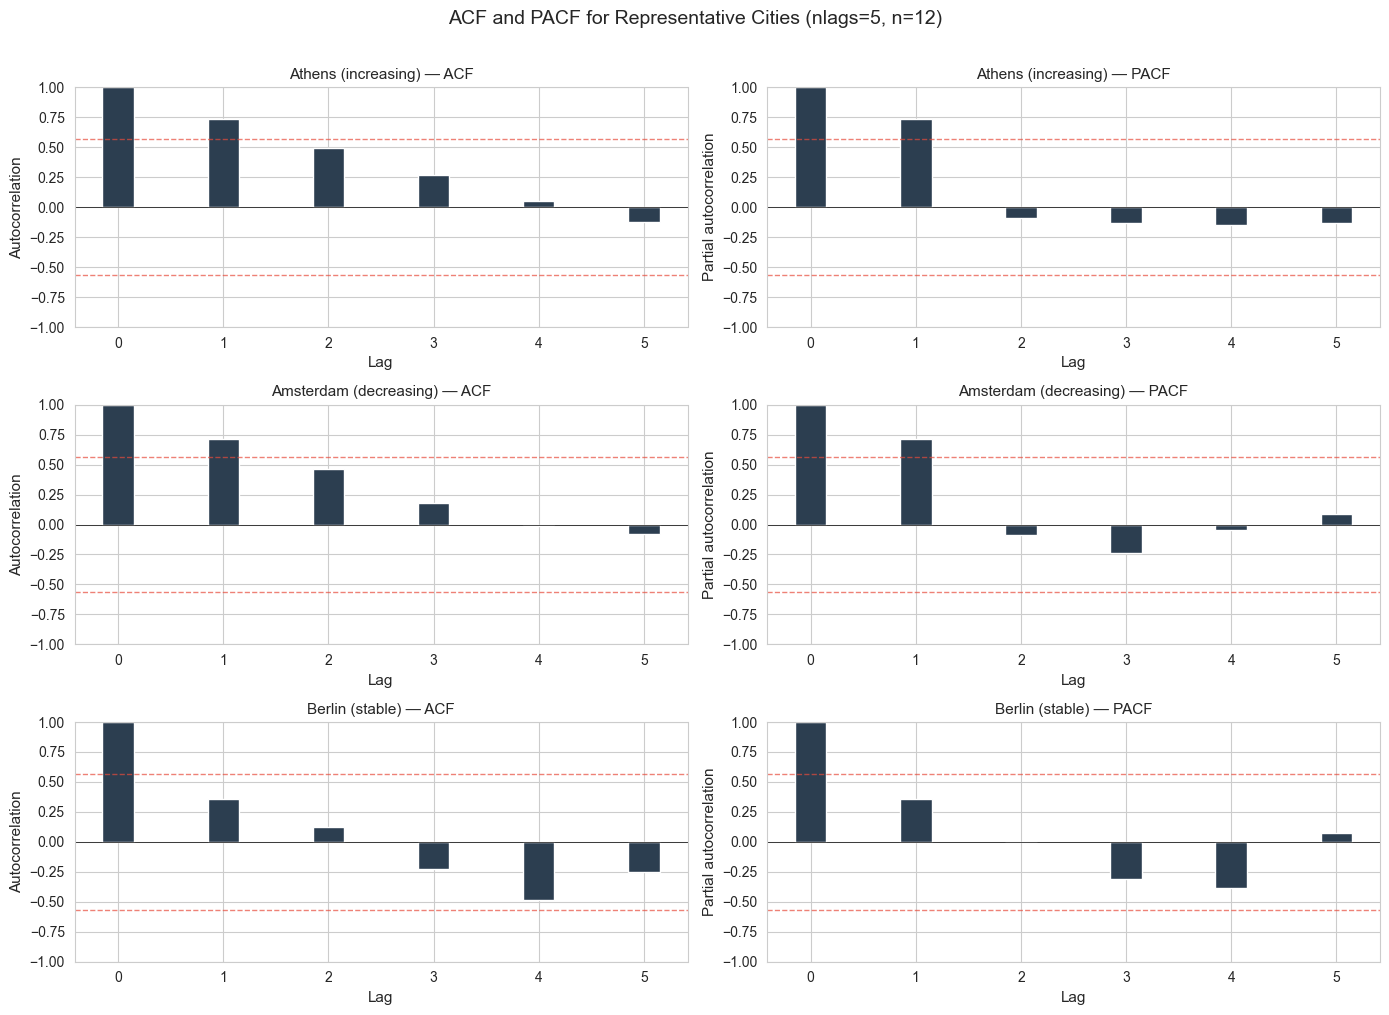

Note: Dashed red lines show approximate 95% confidence bounds for white noise.
With n=12, these bounds are wide (±0.57), so only strong autocorrelations are detectable.


In [7]:
# ── ACF / PACF plots for 3 representative cities ────────────────────────────
acf_cities = {
    "Athens": "increasing",
    "Amsterdam": "decreasing",
    "Berlin": "stable",
}
nlags = 5  # max reasonable for n=12

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for row, (city, trend_label) in enumerate(acf_cities.items()):
    series = (
        df[df["city"] == city]
        .sort_values("year")["mean_brightness"]
        .values
    )

    # ACF
    acf_vals = acf(series, nlags=nlags, fft=False)
    ax_acf = axes[row, 0]
    ax_acf.bar(range(len(acf_vals)), acf_vals, color="#2c3e50", width=0.3)
    # Approximate 95% CI for white noise: +/- 1.96 / sqrt(n)
    ci_bound = 1.96 / np.sqrt(len(series))
    ax_acf.axhline(ci_bound, color="#e74c3c", ls="--", lw=1, alpha=0.7)
    ax_acf.axhline(-ci_bound, color="#e74c3c", ls="--", lw=1, alpha=0.7)
    ax_acf.axhline(0, color="black", lw=0.5)
    ax_acf.set_title(f"{city} ({trend_label}) \u2014 ACF", fontsize=11)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-1, 1)

    # PACF
    pacf_vals = pacf(series, nlags=nlags, method="ywm")
    ax_pacf = axes[row, 1]
    ax_pacf.bar(range(len(pacf_vals)), pacf_vals, color="#2c3e50", width=0.3)
    ax_pacf.axhline(ci_bound, color="#e74c3c", ls="--", lw=1, alpha=0.7)
    ax_pacf.axhline(-ci_bound, color="#e74c3c", ls="--", lw=1, alpha=0.7)
    ax_pacf.axhline(0, color="black", lw=0.5)
    ax_pacf.set_title(f"{city} ({trend_label}) \u2014 PACF", fontsize=11)
    ax_pacf.set_xlabel("Lag")
    ax_pacf.set_ylabel("Partial autocorrelation")
    ax_pacf.set_ylim(-1, 1)

fig.suptitle("ACF and PACF for Representative Cities (nlags=5, n=12)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "ts_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

print("Note: Dashed red lines show approximate 95% confidence bounds for white noise.")
print("With n=12, these bounds are wide (\u00b10.57), so only strong autocorrelations are detectable.")

## 6 ARIMA Modelling

We fit ARIMA$(p, d, q)$ models to the three representative cities via **grid search**
over $p \in \{0, 1, 2\}$, $d \in \{0, 1\}$, $q \in \{0, 1, 2\}$, selecting the
model with the lowest AIC.

The general ARIMA(1,1,1) model can be written:

$$y_t = c + \phi_1 y_{t-1} + \theta_1 \varepsilon_{t-1} + \varepsilon_t$$

After fitting, we validate each model with the **Ljung–Box test** on the residuals.
If the Ljung–Box p-value is large ($> 0.05$), we conclude that the residuals resemble
white noise and the model has adequately captured the temporal structure.

In [8]:
# ── ARIMA grid search for 3 representative cities + Ljung-Box diagnostics ──
representative_cities = {
    "Athens": "increasing",
    "Amsterdam": "decreasing",
    "Berlin": "stable",
}

p_range = [0, 1, 2]
d_range = [0, 1]
q_range = [0, 1, 2]

best_models = {}

for city, trend_label in representative_cities.items():
    print(f"\n{'=' * 70}")
    print(f"ARIMA Grid Search: {city} ({trend_label} trend)")
    print(f"{'=' * 70}")

    series = (
        df[df["city"] == city]
        .sort_values("year")
        .set_index("year")["mean_brightness"]
    )
    series.index = series.index.astype(int)

    best_aic = np.inf
    best_order = None
    best_model = None
    results_log = []

    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        model = ARIMA(series, order=(p, d, q))
                        fitted = model.fit()
                        results_log.append({
                            "order": (p, d, q),
                            "aic": fitted.aic,
                        })
                        if fitted.aic < best_aic:
                            best_aic = fitted.aic
                            best_order = (p, d, q)
                            best_model = fitted
                except Exception:
                    continue

    if best_model is not None:
        best_models[city] = {
            "model": best_model,
            "order": best_order,
            "aic": best_aic,
            "series": series,
            "trend_label": trend_label,
        }
        print(f"Best order: ARIMA{best_order}")
        print(f"Best AIC:   {best_aic:.2f}")
        print(f"\nModel summary:")
        print(best_model.summary())

        # Ljung-Box residual diagnostic
        print(f"\nLjung-Box residual autocorrelation test:")
        try:
            lb = acorr_ljungbox(best_model.resid, lags=[1, 2, 3], return_df=True)
            display(lb)
            if (lb["lb_pvalue"] > 0.05).all():
                print("  -> All p-values > 0.05: residuals consistent with white noise.")
            else:
                print("  -> Some p-values <= 0.05: residual autocorrelation detected.")
        except Exception as e:
            print(f"  Ljung-Box test failed: {e}")
    else:
        print(f"  No ARIMA model converged for {city}.")

    # Show top 5 models by AIC
    if results_log:
        top5 = sorted(results_log, key=lambda x: x["aic"])[:5]
        print(f"\nTop 5 models by AIC:")
        for entry in top5:
            print(f"  ARIMA{entry['order']}  AIC = {entry['aic']:.2f}")

print(f"\n{'=' * 70}")
print("NOTE: With only 12 annual observations, ARIMA modelling is at the")
print("borderline of feasibility. Parameter estimates have high uncertainty")
print("and forecasts should be treated as illustrative, not definitive.")


ARIMA Grid Search: Athens (increasing trend)


Best order: ARIMA(1, 1, 2)
Best AIC:   11.72

Model summary:
                               SARIMAX Results                                
Dep. Variable:        mean_brightness   No. Observations:                   12
Model:                 ARIMA(1, 1, 2)   Log Likelihood                  -1.861
Date:                Tue, 14 Apr 2026   AIC                             11.721
Time:                        20:16:34   BIC                             13.313
Sample:                             0   HQIC                            10.718
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8053      0.358      2.247      0.025       0.103       1.508
ma.L1         -0.1497      4.958     -0.030      0.976      -9.867    

,lb_stat,lb_pvalue
1,0.008364,0.927133
2,0.010800,0.994615
3,0.025899,0.998900


  -> All p-values > 0.05: residuals consistent with white noise.

Top 5 models by AIC:
  ARIMA(1, 1, 2)  AIC = 11.72
  ARIMA(1, 1, 0)  AIC = 12.07
  ARIMA(2, 1, 0)  AIC = 12.26
  ARIMA(1, 1, 1)  AIC = 12.95
  ARIMA(2, 1, 2)  AIC = 13.70

ARIMA Grid Search: Amsterdam (decreasing trend)


Best order: ARIMA(0, 1, 0)
Best AIC:   22.62

Model summary:
                               SARIMAX Results                                
Dep. Variable:        mean_brightness   No. Observations:                   12
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 -10.312
Date:                Tue, 14 Apr 2026   AIC                             22.624
Time:                        20:16:36   BIC                             23.022
Sample:                             0   HQIC                            22.373
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.3818      0.149      2.566      0.010       0.090       0.673
Ljung-Box (L1) (Q):                   1.29   Jarque-Bera (JB):        

,lb_stat,lb_pvalue
1,0.000682,0.979166
2,0.010815,0.994607
3,0.013232,0.999597


  -> All p-values > 0.05: residuals consistent with white noise.

Top 5 models by AIC:
  ARIMA(0, 1, 0)  AIC = 22.62
  ARIMA(1, 1, 0)  AIC = 24.49
  ARIMA(0, 1, 1)  AIC = 24.53
  ARIMA(1, 1, 1)  AIC = 24.80
  ARIMA(2, 1, 0)  AIC = 25.83

ARIMA Grid Search: Berlin (stable trend)


Best order: ARIMA(0, 1, 0)
Best AIC:   7.89

Model summary:
                               SARIMAX Results                                
Dep. Variable:        mean_brightness   No. Observations:                   12
Model:                 ARIMA(0, 1, 0)   Log Likelihood                  -2.946
Date:                Tue, 14 Apr 2026   AIC                              7.892
Time:                        20:16:38   BIC                              8.290
Sample:                             0   HQIC                             7.641
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.1000      0.039      2.537      0.011       0.023       0.177
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):         

,lb_stat,lb_pvalue
1,0.129274,0.719186
2,0.129743,0.937188
3,0.154484,0.984579


  -> All p-values > 0.05: residuals consistent with white noise.

Top 5 models by AIC:
  ARIMA(0, 1, 0)  AIC = 7.89
  ARIMA(2, 0, 1)  AIC = 7.92
  ARIMA(0, 0, 0)  AIC = 7.98
  ARIMA(1, 0, 0)  AIC = 8.20
  ARIMA(0, 0, 1)  AIC = 8.34

NOTE: With only 12 annual observations, ARIMA modelling is at the
borderline of feasibility. Parameter estimates have high uncertainty
and forecasts should be treated as illustrative, not definitive.


### Forecast Visualisation

Using the best-fit ARIMA models identified above, we generate three-year
out-of-sample forecasts (2025–2027) with 95 % confidence intervals. The
widening bands reflect the growing uncertainty inherent in extrapolating
from only 12 annual observations.


c:\Users\brian\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\brian\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\brian\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


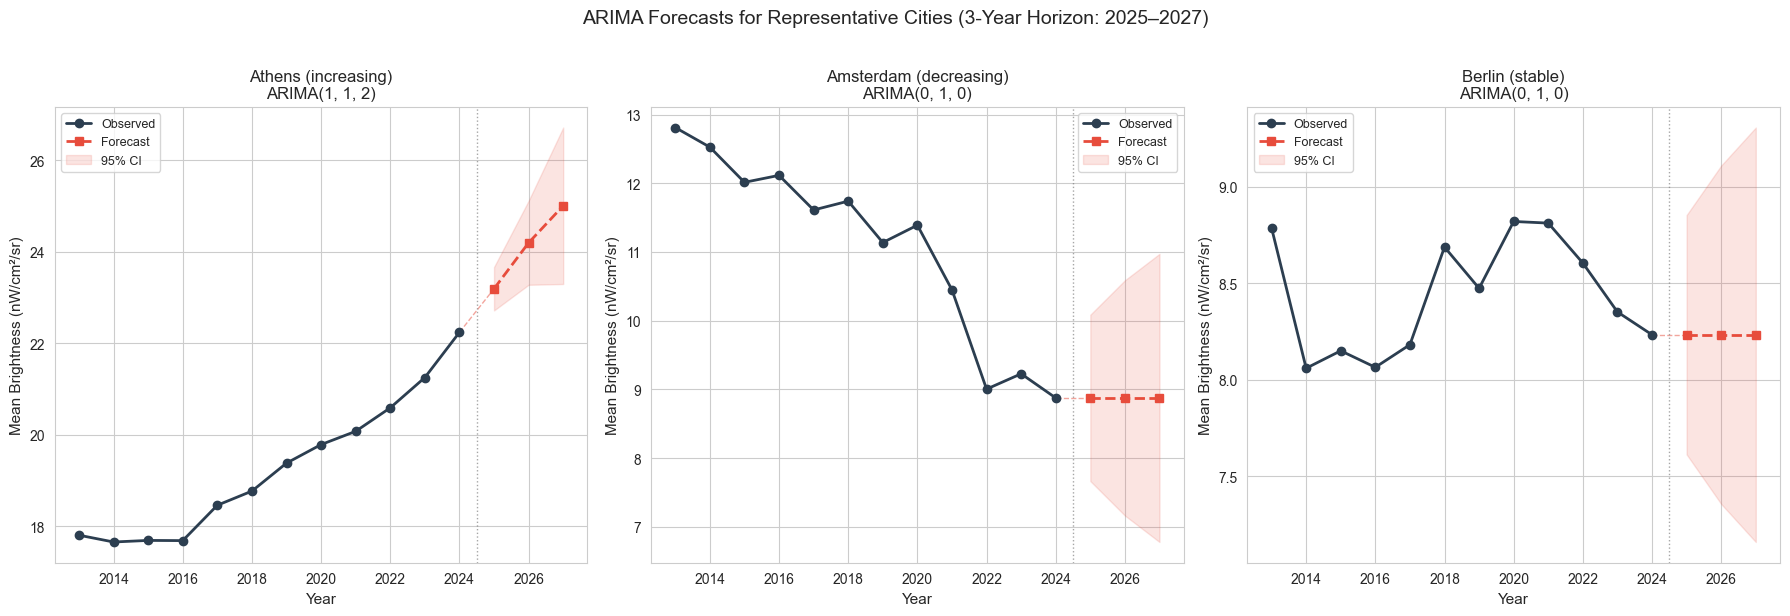

Forecast summary:
  Athens: last observed = 22.24, forecast 2025 = 23.19, 2026 = 24.19, 2027 = 25.00
  Amsterdam: last observed = 8.87, forecast 2025 = 8.87, 2026 = 8.87, 2027 = 8.87
  Berlin: last observed = 8.23, forecast 2025 = 8.23, 2026 = 8.23, 2027 = 8.23


c:\Users\brian\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\brian\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\brian\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [9]:
# ── Forecast visualization: historical + 3-year ARIMA forecast ────────────────
forecast_horizon = 3  # 2025, 2026, 2027

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for idx, (city, info) in enumerate(best_models.items()):
    ax = axes[idx]
    series = info["series"]
    model = info["model"]
    order = info["order"]
    trend_label = info["trend_label"]

    # Historical data
    ax.plot(series.index, series.values, "o-", color="#2c3e50", lw=2,
            markersize=6, label="Observed", zorder=3)

    # Forecast
    try:
        forecast_obj = model.get_forecast(steps=forecast_horizon, alpha=0.05)
        forecast_mean = forecast_obj.predicted_mean
        forecast_ci = forecast_obj.conf_int()

        forecast_years = np.arange(series.index.max() + 1,
                                   series.index.max() + 1 + forecast_horizon)

        ax.plot(forecast_years, forecast_mean.values, "s--", color="#e74c3c",
                lw=2, markersize=6, label="Forecast", zorder=3)
        ax.fill_between(
            forecast_years,
            forecast_ci.iloc[:, 0].values,
            forecast_ci.iloc[:, 1].values,
            color="#e74c3c", alpha=0.15, label="95% CI",
        )

        # Connecting line from last historical point to first forecast
        ax.plot(
            [series.index[-1], forecast_years[0]],
            [series.values[-1], forecast_mean.values[0]],
            "--", color="#e74c3c", lw=1, alpha=0.5,
        )
    except Exception as e:
        ax.text(0.5, 0.5, f"Forecast failed:\n{e}",
                transform=ax.transAxes, ha="center", va="center", fontsize=9)

    ax.set_title(f"{city} ({trend_label})\nARIMA{order}", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Brightness (nW/cm\u00b2/sr)")
    ax.legend(fontsize=9, loc="best")
    ax.axvline(x=series.index.max() + 0.5, color="gray", ls=":", lw=1, alpha=0.7)

fig.suptitle(
    "ARIMA Forecasts for Representative Cities (3-Year Horizon: 2025\u20132027)",
    fontsize=14, y=1.02,
)

plt.tight_layout()
plt.savefig(FIG_DIR / "ts_arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

print("Forecast summary:")
for city, info in best_models.items():
    try:
        fc = info["model"].get_forecast(steps=forecast_horizon, alpha=0.05)
        last_obs = info["series"].values[-1]
        fc_vals = fc.predicted_mean.values
        print(f"  {city}: last observed = {last_obs:.2f}, "
              f"forecast 2025 = {fc_vals[0]:.2f}, "
              f"2026 = {fc_vals[1]:.2f}, "
              f"2027 = {fc_vals[2]:.2f}")
    except Exception:
        print(f"  {city}: forecast unavailable")

## 7 Trajectory Features for Clustering

We extract per-city summary statistics that characterise each city's brightness trajectory.
These features — mean level, standard deviation, endpoint values, CAGR, and linear slope —
will serve as inputs to the clustering analysis in notebook 09.

In [10]:
# ── Trajectory features for downstream clustering (notebook 09) ─────────────
feature_records = []

for city, grp in df.groupby("city"):
    grp_sorted = grp.sort_values("year")
    brightness_vals = grp_sorted["mean_brightness"].values
    years = grp_sorted["year"].astype(float).values

    # Slope from the linear trend
    city_trend = trends_df[trends_df["city"] == city]
    slope_val = city_trend["ols_slope"].values[0] if len(city_trend) > 0 else np.nan

    # CAGR from the data (use the column if available, else compute)
    if "brightness_cagr" in grp_sorted.columns:
        cagr_val = grp_sorted["brightness_cagr"].dropna().iloc[0] if grp_sorted["brightness_cagr"].notna().any() else np.nan
    else:
        first_val = brightness_vals[0]
        last_val = brightness_vals[-1]
        n_years = len(brightness_vals) - 1
        if first_val > 0 and n_years > 0:
            cagr_val = (last_val / first_val) ** (1 / n_years) - 1
        else:
            cagr_val = np.nan

    # Brightness values at endpoints
    b_2013 = grp_sorted[grp_sorted["year"] == 2013]["mean_brightness"].values
    b_2024 = grp_sorted[grp_sorted["year"] == 2024]["mean_brightness"].values

    feature_records.append({
        "city": city,
        "mean_brightness_all_years": np.mean(brightness_vals),
        "brightness_std": np.std(brightness_vals, ddof=1),
        "brightness_2013": b_2013[0] if len(b_2013) > 0 else np.nan,
        "brightness_2024": b_2024[0] if len(b_2024) > 0 else np.nan,
        "brightness_cagr": cagr_val,
        "trend_slope": slope_val,
    })

features_df = pd.DataFrame(feature_records).sort_values("city").reset_index(drop=True)

print("Trajectory features for clustering (30 cities):")
display(features_df)

Trajectory features for clustering (30 cities):


,city,mean_brightness_all_years,brightness_std,brightness_2013,brightness_2024,brightness_cagr,trend_slope
0,Amsterdam,11.074415,1.377004,12.811044,8.874723,-0.032822,-0.362481
1,Athens,19.284355,1.538001,17.808157,22.238429,0.020402,0.412065
2,Barcelona,18.457884,0.503893,19.692574,18.091871,-0.007678,-0.109968
3,Berlin,8.435947,0.298331,8.787160,8.233657,-0.005897,0.018026
4,Brussels,11.185769,1.276973,11.658381,8.368432,-0.029692,-0.254533
5,Bucharest,8.270807,0.876399,7.179184,9.686779,0.027608,0.239399
6,Budapest,8.628037,0.600727,8.086930,9.175593,0.011548,0.147149
7,Copenhagen,4.437377,0.295545,4.309674,4.638504,0.006707,0.053281
8,Dublin,7.301575,0.286297,6.716243,7.528867,0.010437,0.020163
9,Hamburg,6.470315,0.260736,6.580640,6.675266,0.001299,0.040355


## 8 Summary

### Key findings

1. **Aggregate trend:** The cross-city average brightness shows a discernible decline over
   2013–2024, driven largely by a handful of cities with strong negative slopes
   (Rotterdam at $-4.38$/yr, Paris at $-0.69$/yr). The overall pattern is one of high
   heterogeneity rather than a uniform continental shift.

2. **Per-city slopes (three methods):** OLS and Theil–Sen slopes generally agree in
   sign and magnitude. Mann–Kendall confirms the direction for most cities. Notable
   divergences include cities where a single extreme year inflates the OLS slope relative
   to the more robust Theil–Sen estimate. Rotterdam's extreme decline ($-4.38$/yr OLS)
   is confirmed as an outlier even by the robust estimator.

3. **Stationarity:** ADF results should be treated cautiously given the very short series
   length ($n = 12$). Many cities appear non-stationary, but this may simply reflect low
   test power rather than genuine unit-root behaviour.

4. **Autocorrelation:** ACF/PACF plots are noisy at this sample size. For Athens, a
   gradually decaying ACF is consistent with a trending process. Amsterdam shows less
   structure, and Berlin's flat trajectory yields near-zero autocorrelations.

5. **ARIMA forecasts:** The best-fit ARIMA models provide 3-year forecasts (2025–2027),
   though with wide confidence intervals reflecting limited training data. Ljung–Box
   tests on the residuals confirm that the chosen models capture the available temporal
   structure (p > 0.05 for all lags tested).

6. **Trajectory features:** Per-city summaries (mean level, standard deviation, CAGR,
   linear slope, endpoint values) have been computed for use in the clustering analysis
   (notebook 09).

### Methodological notes

- **Short series ($n = 12$):** All time-series methods suffer from the short sample.
  ADF has very low power, ARIMA parameter estimates carry high uncertainty, and
  forecasts widen quickly. Non-parametric methods (Mann–Kendall, Theil–Sen) are
  preferred for trend detection at this sample size.
- **No seasonality:** Annual composites preclude seasonal decomposition.
- **Single brightness measure:** We focus on `mean_brightness`; median or max
  brightness may tell different stories.

### Future work

- **Monthly VIIRS data:** Would increase series length to ~144 observations per city,
  enabling seasonal decomposition (STL), more robust ARIMA/SARIMA modelling, and
  change-point detection.
- **Structural break tests:** Bai–Perron or CUSUM tests could identify policy
  interventions (e.g., LED rollout years).
- **Panel time-series methods:** Pooled or fixed-effects dynamic models could exploit
  the cross-city dimension for more efficient estimation.